# Week 3: Data Prepocessing

============================================================

IDX Exchange — Data Science Internship

Week 3: Data Preprocessing

Author: Zachary Blehm

============================================================

Summary:



*   





In [126]:
# Imports and File Loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import files
from sklearn.neighbors import NearestNeighbors
import warnings
from numpy.polynomial.polynomial import Polynomial
from numpy.polynomial.polyutils import RankWarning

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [127]:
# 28 months of data total
# Use up 26 months of data for training (split at 6, 9, 12, 15 for tuning)
# Hold out 202603 for validation & 202604 for testing
data_dir = Path('data')
training_files = [
    'CRMLSSold202401_filled.csv',
    'CRMLSSold202402.csv',
    'CRMLSSold202403_filled.csv',
    'CRMLSSold202404_filled.csv',
    'CRMLSSold202405_filled.csv',
    'CRMLSSold202406_filled.csv',
    'CRMLSSold202407_filled.csv',
    'CRMLSSold202408.csv',
    'CRMLSSold202409.csv',
    'CRMLSSold202410.csv',
    'CRMLSSold202411.csv',
    'CRMLSSold202412.csv',
    'CRMLSSold202501_filled.csv',
    'CRMLSSold202502.csv',
    'CRMLSSold202503.csv',
    'CRMLSSold202504.csv',
    'CRMLSSold202505.csv',
    'CRMLSSold202506.csv',
    'CRMLSSold202507.csv',
    'CRMLSSold202508.csv',
    'CRMLSSold202509.csv',
    'CRMLSSold202510.csv',
    'CRMLSSold202511.csv',
    'CRMLSSold202512.csv',
    'CRMLSSold202601.csv',
    'CRMLSSold202602.csv',
    'CRMLSSold202603.csv',
    'CRMLSSold202604.csv'
]

dfs = [pd.read_csv(f, low_memory = False) for f in training_files]
df = pd.concat(dfs, ignore_index=True)
print('Combined training shape:', df.shape)

Combined training shape: (615707, 84)


# Helper Functions

In [128]:
# Track rows removed (logging helper function)
cleaning_log = []

def log_step(step, df_before, df_after):
    rows_before = len(df_before)
    rows_after = len(df_after)
    rows_removed = rows_before - rows_after
    pct_removed = round((rows_removed / rows_before) * 100, 3)

    cleaning_log.append({
        "Step": step,
        "Rows Before": rows_before,
        "Rows After": rows_after,
        "Rows Removed": rows_removed,
        "Percent Removed": pct_removed
    })

# Initial Filtering of the Data

Filter the data for "Residential" and "SingleFamilyResidence" per the task of predicing home prices.

In [129]:
# Filter the data based on the desired type and subtype

df = df[
    (df['PropertyType'] == 'Residential') &
    (df['PropertySubType'] == 'SingleFamilyResidence')
].copy()
print('After filter:', df.shape)

After filter: (309735, 84)


Keep only the Core property charactersists and a few other columns of interest for further investigation.

In [130]:
# List of columns to keep for the initial investigation
keep_columns = [
    # Target
    "ClosePrice",

    # Primary Key - use to remove duplicates then drop
    "ListingKey",

    # Core property characteristics
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",

    # Location
    "PostalCode",
    "Latitude",
    "Longitude",
    # Use to fill NULL Lat and Lon then drop
    "latfilled",
    "lonfilled",

    # Property features
    "ViewYN",
    "AttachedGarageYN",
    "ParkingTotal",
    "FireplaceYN",
    "Stories",
    "Levels",
    "MainLevelBedrooms",
    "NewConstructionYN",
    "GarageSpaces",

    # HOA
    "AssociationFee",
    "AssociationFeeFrequency",

    # Date
    "CloseDate"
]

df_clean = df[keep_columns].copy()

print("Original shape:", df.shape)
print("Candidate modeling shape:", df_clean.shape)

Original shape: (309735, 84)
Candidate modeling shape: (309735, 24)


# Drop Duplicates

In [131]:
# Remove duplicates (retain most recent)
df_before = df_clean.copy()

df_clean = df_clean.sort_values("CloseDate")
df_clean = df_clean.drop_duplicates(subset="ListingKey", keep="last")

log_step(
    "Remove rows with duplicate listing key (retain most recent)",
    df_before,
    df_clean
)

display(cleaning_log)

# Drop ListingKey since it is no longer needed
df_clean = df_clean.drop(columns=["ListingKey"])
keep_columns.remove("ListingKey")

[{'Step': 'Remove rows with duplicate listing key (retain most recent)',
  'Rows Before': 309735,
  'Rows After': 309471,
  'Rows Removed': 264,
  'Percent Removed': 0.085}]

# Datatype Conversion for Numeric and Dates

In [132]:
# Define and then columns that should be numeric type
numeric_columns = [
    "ClosePrice",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "ParkingTotal",
    "Stories",
    "MainLevelBedrooms",
    "GarageSpaces",
    "AssociationFee",
    "latfilled",
    "lonfilled"
]

# Convert the numeric columns to numeric type
for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [133]:
df_clean["CloseDate"] = pd.to_datetime(df_clean["CloseDate"])

# Add Missingness Indicator to Y/N Colunms and Convert to 0/1.

In [134]:
# Define the columns that have Y/N values
# The actual values are True and False
yn_columns = [
    "ViewYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN"
]

for col in yn_columns:
    # Missingness indicator
    df_clean[f"{col}_missing"] = df_clean[col].isna().astype("int64")

    # Convert True to 1 and False/NaN to 0
    df_clean[col] = (
        df_clean[col]
        .map({True: 1, False: 0})
        .fillna(0)
        .astype("int64")
    )

# Stadardize PostalCode

In [135]:
# Standardize PostaclCode to 5 digits (i.e. drop extra 4 digits if they exist)
df_clean["PostalCode"] = (
    df_clean["PostalCode"]
    .astype(str)
    .str.extract(r"(\d{5})")  # extract the first 5 digits
)

## Check Null Percentages per Column

In [136]:
# Look at percent missing for each column

print("\nPercentage missing:")
print(
    (df_clean[keep_columns].isna().mean() * 100)
    .round(3)
)


Percentage missing:
ClosePrice                  0.000
BedroomsTotal               0.000
BathroomsTotalInteger       0.016
LivingArea                  0.054
LotSizeSquareFeet           1.720
YearBuilt                   0.073
PostalCode                  0.000
Latitude                    0.876
Longitude                   0.876
latfilled                  73.979
lonfilled                  73.979
ViewYN                      0.000
AttachedGarageYN            0.000
ParkingTotal                0.112
FireplaceYN                 0.000
Stories                    12.718
Levels                      9.447
MainLevelBedrooms          40.300
NewConstructionYN           0.000
GarageSpaces                3.722
AssociationFee             30.231
AssociationFeeFrequency    74.866
CloseDate                   0.000
dtype: float64


All the primary columns have very low missing value percentages, but we see some columns with double digit missing value percentages that will need special attention and some columns with lower percentage of missing values which will be handled with imputation.

## Remove Rows with NULL values

In [137]:
# Define the primary columns & remove any rows that have a null value
primary_columns = [
    "ClosePrice",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LivingArea",
    "LotSizeSquareFeet",
    "PostalCode"
]

In [138]:
# Remove rows with NULL for the primary columns
df_before = df_clean.copy()

df_clean = df_clean.dropna(
    subset=primary_columns
).copy()

log_step(
    "Remove rows missing primary fields",
    df_before,
    df_clean
)

display(cleaning_log)

[{'Step': 'Remove rows with duplicate listing key (retain most recent)',
  'Rows Before': 309735,
  'Rows After': 309471,
  'Rows Removed': 264,
  'Percent Removed': 0.085},
 {'Step': 'Remove rows missing primary fields',
  'Rows Before': 309471,
  'Rows After': 303930,
  'Rows Removed': 5541,
  'Percent Removed': 1.79}]

## Remove Unrealistic Values & Outliers

In [139]:
# Remove rows with ClosePrice <= 0
df_before = df_clean.copy()

df_clean = df_clean[
    df_clean["ClosePrice"] > 0
].copy()

log_step(
    "Remove ClosePrice <= 0",
    df_before,
    df_clean
)

display(cleaning_log)

[{'Step': 'Remove rows with duplicate listing key (retain most recent)',
  'Rows Before': 309735,
  'Rows After': 309471,
  'Rows Removed': 264,
  'Percent Removed': 0.085},
 {'Step': 'Remove rows missing primary fields',
  'Rows Before': 309471,
  'Rows After': 303930,
  'Rows Removed': 5541,
  'Percent Removed': 1.79},
 {'Step': 'Remove ClosePrice <= 0',
  'Rows Before': 303930,
  'Rows After': 303929,
  'Rows Removed': 1,
  'Percent Removed': 0.0}]

In [140]:
# Remove primary columns (less PostalCode) with unrealistic values
df_before = df_clean.copy()

df_clean = df_clean[
    (df_clean["LivingArea"] > 0) &
    (df_clean["LotSizeSquareFeet"] > 0) &
    (df_clean["BedroomsTotal"] >= 0) &
    (df_clean["BathroomsTotalInteger"] >= 0)
].copy()

log_step("Remove logical impossibilities (area/bed/bath)", df_before, df_clean)

display(cleaning_log)

[{'Step': 'Remove rows with duplicate listing key (retain most recent)',
  'Rows Before': 309735,
  'Rows After': 309471,
  'Rows Removed': 264,
  'Percent Removed': 0.085},
 {'Step': 'Remove rows missing primary fields',
  'Rows Before': 309471,
  'Rows After': 303930,
  'Rows Removed': 5541,
  'Percent Removed': 1.79},
 {'Step': 'Remove ClosePrice <= 0',
  'Rows Before': 303930,
  'Rows After': 303929,
  'Rows Removed': 1,
  'Percent Removed': 0.0},
 {'Step': 'Remove logical impossibilities (area/bed/bath)',
  'Rows Before': 303929,
  'Rows After': 303642,
  'Rows Removed': 287,
  'Percent Removed': 0.094}]

# Restrict to California PostalCodes

In [141]:
# Remove PostalCode not in California
df_before = df_clean.copy()

df_clean = df_clean[
    (df_clean["PostalCode"] >= '90001') &
    (df_clean["PostalCode"] <= '96162')
].copy()

log_step(
    "Remove PostalCodes not in California",
    df_before,
    df_clean
)

display(cleaning_log)

[{'Step': 'Remove rows with duplicate listing key (retain most recent)',
  'Rows Before': 309735,
  'Rows After': 309471,
  'Rows Removed': 264,
  'Percent Removed': 0.085},
 {'Step': 'Remove rows missing primary fields',
  'Rows Before': 309471,
  'Rows After': 303930,
  'Rows Removed': 5541,
  'Percent Removed': 1.79},
 {'Step': 'Remove ClosePrice <= 0',
  'Rows Before': 303930,
  'Rows After': 303929,
  'Rows Removed': 1,
  'Percent Removed': 0.0},
 {'Step': 'Remove logical impossibilities (area/bed/bath)',
  'Rows Before': 303929,
  'Rows After': 303642,
  'Rows Removed': 287,
  'Percent Removed': 0.094},
 {'Step': 'Remove PostalCodes not in California',
  'Rows Before': 303642,
  'Rows After': 303598,
  'Rows Removed': 44,
  'Percent Removed': 0.014}]

In [142]:
# Remove outlier bedroom and bathroom counts
df_before = df_clean.copy()

df_clean = df_clean[
    (df_clean["BedroomsTotal"] >= 1) &
    (df_clean["BedroomsTotal"] <= 12) &
    (df_clean["BathroomsTotalInteger"] >= 1) &
    (df_clean["BathroomsTotalInteger"] <= 12)
].copy()

log_step(
    "Remove outlier bedroom/bathroom counts",
    df_before,
    df_clean
)

display(cleaning_log)

[{'Step': 'Remove rows with duplicate listing key (retain most recent)',
  'Rows Before': 309735,
  'Rows After': 309471,
  'Rows Removed': 264,
  'Percent Removed': 0.085},
 {'Step': 'Remove rows missing primary fields',
  'Rows Before': 309471,
  'Rows After': 303930,
  'Rows Removed': 5541,
  'Percent Removed': 1.79},
 {'Step': 'Remove ClosePrice <= 0',
  'Rows Before': 303930,
  'Rows After': 303929,
  'Rows Removed': 1,
  'Percent Removed': 0.0},
 {'Step': 'Remove logical impossibilities (area/bed/bath)',
  'Rows Before': 303929,
  'Rows After': 303642,
  'Rows Removed': 287,
  'Percent Removed': 0.094},
 {'Step': 'Remove PostalCodes not in California',
  'Rows Before': 303642,
  'Rows After': 303598,
  'Rows Removed': 44,
  'Percent Removed': 0.014},
 {'Step': 'Remove outlier bedroom/bathroom counts',
  'Rows Before': 303598,
  'Rows After': 303359,
  'Rows Removed': 239,
  'Percent Removed': 0.079}]

# Examine High Null Rate Columns (Stories, Levels and MainLevelBedrooms)

## Stories and Levels

In [143]:
display(df_clean[['Stories', 'Levels']].value_counts(dropna=False))

Stories  Levels                        
1.0      One                               170288
2.0      Two                                91965
NaN      NaN                                28958
         ThreeOrMore                         5570
         MultiSplit                          4196
1.0      One,Two                              653
2.0      Two,MultiSplit                       456
1.0      Two,One                              257
         NaN                                  231
NaN      ThreeOrMore,MultiSplit               206
1.0      Two                                  186
         One,MultiSplit                       166
2.0      Two,ThreeOrMore                      107
1.0      One,ThreeOrMore                       47
         MultiSplit,One                        26
         MultiSplit                            13
         One,Two,MultiSplit                    10
2.0      Two,ThreeOrMore,MultiSplit             7
1.0      One,Two,ThreeOrMore                    6
         ThreeOrMore,One                        6
         One,Two,ThreeOrMore,MultiSplit         3
         Two,MultiSplit,One                     1
         ThreeOrMore                            1
Name: count, dtype: int64

Most of the nulls in these two columns overlap. But in examining Levels we see the data in this columns is not as expected. Levels should be an ENUM type, so the contradictory comma separated values are hard to understand.

In [144]:
pd.crosstab(df_clean["Levels"], df_clean["Stories"])

Stories,1.0,2.0
Levels,,
MultiSplit,13,0
"MultiSplit,One",26,0
One,170288,0
"One,MultiSplit",166,0
"One,ThreeOrMore",47,0
"One,Two",653,0
"One,Two,MultiSplit",10,0
"One,Two,ThreeOrMore",6,0
"One,Two,ThreeOrMore,MultiSplit",3,0


We see that most of the data in Levels is redundant with the data we have in Stories.

In [145]:
df_clean["Levels"].astype("category").cat.codes.corr(df_clean["ClosePrice"])


np.float64(0.021631744027267485)

Finally we see that Levels offers very little in the way of predictive value. Based on the factors of the Levels being messy data, mostly redundant with Stories and having low correlation with ClosePrice, the column is dropped. For now we retain a missingness indicator for the column and will keep or drop Levels_misisng based on correlation later in this process.

On the other hand Stories is retained. Nulls will be imputed to the mode of the column later on a training set by training set basis. For now we simply retain the column.

In [146]:
# Missingness indicator
df_clean["Levels_missing"] = df_clean["Levels"].isna().astype("int64")

# Drop Levels entirely
df_clean = df_clean.drop(columns=["Levels"])
keep_columns.remove("Levels")

In [147]:
# Missingness indicator
df_clean["Stories_missing"] = df_clean["Stories"].isna().astype("int64")

# Impute missing Stories with mode
stories_mode = df_clean["Stories"].mode()[0]
df_clean["Stories"] = df_clean["Stories"].fillna(stories_mode).astype("int64")

## MainLevelBedrooms

In [148]:
df_clean.groupby(df_clean["MainLevelBedrooms"].isna())["ClosePrice"].median()


,ClosePrice
MainLevelBedrooms,
False,785000.0
True,1191800.0


There is quite a large difference in ClosePrice based on MainLevelBedrooms being NULL or some Value, it seems NULL vs. NOT NULL may be predictive in some way.

In [149]:
df_clean["MainLevelBedrooms"].corr(df_clean["ClosePrice"])

np.float64(-0.0034445742548998752)

We also see no correlation for MainLevelBedroom with ClosePrice. Given the high null percentage and lack of correlation MainLevelBedrooms is dropped while retaining a missingness indicator.

In [150]:
# Add missingness indicator
df_clean["MainLevelBedrooms_missing"] = df_clean["MainLevelBedrooms"].isna().astype("int64")

# Drop the original column
df_clean = df_clean.drop(columns=["MainLevelBedrooms"])
keep_columns.remove("MainLevelBedrooms")

## AssociationFee and AssociationFeeFrequency

In [151]:
fee_cat = (
    df_clean["AssociationFee"]
    .pipe(lambda s: pd.Series(
        np.where(s.isna(), "Null",
        np.where(s == 0, "Zero", "NonZero")),
        index=s.index
    ))
)

pd.crosstab(
    fee_cat,
    df_clean["AssociationFeeFrequency"].isna(),
    rownames=["Fee Category"],
    colnames=["Frequency is null"]
)

Frequency is null,False,True
Fee Category,,
NonZero,75414,703
Null,51,89722
Zero,183,137286


We see that the vast majority of AssociationFeeFrequency NULL values are when AssociationFee is NULL or zero. We assume that NULL AssocitionFee means no fee, so we impute this value. For the remaining 706 AssociationFeeFrequency NULL values when Association Fee is not NULL and also non-zero we impute with 'Annually' as the most conservative choice. In this way we can convert these two columns to a single HOA_AnnualFee column, and then drop AssociationFee and AssociationFeeFrequency.

In [152]:
def compute_hoa_annual_fee(df):
    # Frequency to multiplier for the fee (convert all to annually)
    freq_map = {
        "Monthly": 12,
        "Quarterly": 4,
        "SemiAnnually": 2,
        "Annually": 1
    }

    # Start with zeros (handles null freq & null fee case)
    df["HOA_AnnualFee"] = 0.0

    # Case 2: Frequency provided
    mask_freq = df["AssociationFeeFrequency"].notna() & (df["AssociationFee"] > 0)
    df.loc[mask_freq, "HOA_AnnualFee"] = (
        df.loc[mask_freq, "AssociationFee"] *
        df.loc[mask_freq, "AssociationFeeFrequency"].map(freq_map).fillna(1)
    )

    # Case 3: Frequency missing but fee > 0 treat as an annual fee
    mask_ambiguous = df["AssociationFeeFrequency"].isna() & (df["AssociationFee"] > 0)
    df.loc[mask_ambiguous, "HOA_AnnualFee"] = df.loc[mask_ambiguous, "AssociationFee"]

    return df

In [153]:
# Create the HOA_AnnualFee column and drop redundant data
df_clean = compute_hoa_annual_fee(df_clean)

df_clean = df_clean.drop(columns=[
    "AssociationFee",
    "AssociationFeeFrequency"
])
keep_columns.remove("AssociationFee")
keep_columns.remove("AssociationFeeFrequency")

# Low Null Rate Columns

## GarageSpaces and ParkingTotal

In [154]:
# Missingness indicators for GarageSpaces and ParkingTotal

df_clean["GarageSpaces_missing"] = df_clean["GarageSpaces"].isna().astype("int64")
df_clean["ParkingTotal_missing"] = df_clean["ParkingTotal"].isna().astype("int64")


In [155]:
# 1. AttachedGarageYN = 1 but GarageSpaces < 1
inconsistent_garage_spaces = df_clean[
    (df_clean["AttachedGarageYN"] == 1) &
    (df_clean["GarageSpaces"] < 1)
]

# 2. AttachedGarageYN = 1 but ParkingTotal < 1
inconsistent_parking_attached = df_clean[
    (df_clean["AttachedGarageYN"] == 1) &
    (df_clean["ParkingTotal"] < 1)
]

# 3. ParkingTotal < GarageSpaces (impossible)
inconsistent_parking_vs_garage = df_clean[
    df_clean["ParkingTotal"] < df_clean["GarageSpaces"]
]

print("Inconsistencies BEFORE repair:")
print(f"Attached garage but GarageSpaces < 1: {len(inconsistent_garage_spaces)}")
print(f"Attached garage but ParkingTotal < 1: {len(inconsistent_parking_attached)}")
print(f"ParkingTotal < GarageSpaces: {len(inconsistent_parking_vs_garage)}")


Inconsistencies BEFORE repair:
Attached garage but GarageSpaces < 1: 570
Attached garage but ParkingTotal < 1: 1064
ParkingTotal < GarageSpaces: 1028


In [156]:
# Repair 1: Attached garage implies GarageSpaces >= 1
df_clean.loc[
    (df_clean["AttachedGarageYN"] == 1) &
    (df_clean["GarageSpaces"] < 1),
    "GarageSpaces"
] = 1

# Repair 2: Attached garage implies ParkingTotal >= 1
df_clean.loc[
    (df_clean["AttachedGarageYN"] == 1) &
    (df_clean["ParkingTotal"] < 1),
    "ParkingTotal"
] = 1

# Repair 3: ParkingTotal must be >= GarageSpaces
df_clean.loc[
    df_clean["ParkingTotal"] < df_clean["GarageSpaces"],
    "ParkingTotal"
] = df_clean["GarageSpaces"]


## Latitude and Longitude

In [157]:
# Count missing original coordinates
missing_lat = df_clean["Latitude"].isna().sum()
missing_lon = df_clean["Longitude"].isna().sum()

df_before = df_clean.copy()

# Fill missing Latitude/Longitude using latfilled/lonfilled
df_clean["Latitude"] = df_clean["Latitude"].fillna(df_clean["latfilled"])
df_clean["Longitude"] = df_clean["Longitude"].fillna(df_clean["lonfilled"])

# Count remaining missing (should be very small)
remaining_lat = df_clean["Latitude"].isna().sum()
remaining_lon = df_clean["Longitude"].isna().sum()

# Drop rows only if BOTH coordinates are still missing
df_clean = df_clean.dropna(subset=["Latitude", "Longitude"]).copy()

log_step(
    f"Fill missing Latitude/Longitude using latfilled/lonfilled "
    f"(original missing: lat={missing_lat}, lon={missing_lon}; "
    f"remaining missing after fill: lat={remaining_lat}, lon={remaining_lon})",
    df_before,
    df_clean
)

display(cleaning_log)

# Drop latfilled and lonfilled
df_clean = df_clean.drop(columns=["latfilled"])
keep_columns.remove("latfilled")

df_clean = df_clean.drop(columns=["lonfilled"])
keep_columns.remove("lonfilled")

[{'Step': 'Remove rows with duplicate listing key (retain most recent)',
  'Rows Before': 309735,
  'Rows After': 309471,
  'Rows Removed': 264,
  'Percent Removed': 0.085},
 {'Step': 'Remove rows missing primary fields',
  'Rows Before': 309471,
  'Rows After': 303930,
  'Rows Removed': 5541,
  'Percent Removed': 1.79},
 {'Step': 'Remove ClosePrice <= 0',
  'Rows Before': 303930,
  'Rows After': 303929,
  'Rows Removed': 1,
  'Percent Removed': 0.0},
 {'Step': 'Remove logical impossibilities (area/bed/bath)',
  'Rows Before': 303929,
  'Rows After': 303642,
  'Rows Removed': 287,
  'Percent Removed': 0.094},
 {'Step': 'Remove PostalCodes not in California',
  'Rows Before': 303642,
  'Rows After': 303598,
  'Rows Removed': 44,
  'Percent Removed': 0.014},
 {'Step': 'Remove outlier bedroom/bathroom counts',
  'Rows Before': 303598,
  'Rows After': 303359,
  'Rows Removed': 239,
  'Percent Removed': 0.079},
 {'Step': 'Fill missing Latitude/Longitude using latfilled/lonfilled (original m

# Temporal Features from CloseDate

In [158]:
# Parse CloseDate to create columns for year, month and quarter
df_clean["CloseYear"] = df_clean["CloseDate"].dt.year
df_clean["CloseMonth"] = df_clean["CloseDate"].dt.month
df_clean["CloseQuarter"] = df_clean["CloseDate"].dt.quarter

In [159]:
# Cyclic encoding of months
df_clean["CloseMonth_sin"] = np.sin(2 * np.pi * df_clean["CloseMonth"] / 12)
df_clean["CloseMonth_cos"] = np.cos(2 * np.pi * df_clean["CloseMonth"] / 12)


# Split into Train/Validation/Test Sets

In [160]:
# Validation = 202603, Test = 202604
val_mask = (df_clean["CloseDate"].dt.year == 2026) & (df_clean["CloseDate"].dt.month == 3)
test_mask = (df_clean["CloseDate"].dt.year == 2026) & (df_clean["CloseDate"].dt.month == 4)

df_val = df_clean[val_mask].copy()
df_test = df_clean[test_mask].copy()

train_full = df_clean[~(val_mask | test_mask)].copy()

# Remove Outliers


In [161]:
# use percentile filtering, keeping middle 99%
def compute_cutoffs(train, col, lower=0.005, upper=0.995):
    lo = train[col].quantile(lower)
    hi = train[col].quantile(upper)
    return lo, hi

cp_lo, cp_hi = compute_cutoffs(train_full, "ClosePrice")
la_lo, la_hi = compute_cutoffs(train_full, "LivingArea")
ls_lo, ls_hi = compute_cutoffs(train_full, "LotSizeSquareFeet")

In [162]:
def apply_cutoffs(df, col, lo, hi):
    return df[(df[col] >= lo) & (df[col] <= hi)].copy()

train_full = apply_cutoffs(train_full, "ClosePrice", cp_lo, cp_hi)
df_val     = apply_cutoffs(df_val,     "ClosePrice", cp_lo, cp_hi)
df_test    = apply_cutoffs(df_test,    "ClosePrice", cp_lo, cp_hi)

train_full = apply_cutoffs(train_full, "LivingArea", la_lo, la_hi)
df_val     = apply_cutoffs(df_val,     "LivingArea", la_lo, la_hi)
df_test    = apply_cutoffs(df_test,    "LivingArea", la_lo, la_hi)

train_full = apply_cutoffs(train_full, "LotSizeSquareFeet", ls_lo, ls_hi)
df_val     = apply_cutoffs(df_val,     "LotSizeSquareFeet", ls_lo, ls_hi)
df_test    = apply_cutoffs(df_test,    "LotSizeSquareFeet", ls_lo, ls_hi)


# Imputation of GarageSpaces based on Median (PostalCode level) values in the Training Set

In [163]:
# Compute ZIP-level medians on training only
garage_median_zip = train_full.groupby("PostalCode")["GarageSpaces"].median()

# Compute global median fallback on training only
global_median_gs = train_full["GarageSpaces"].median()


In [164]:
def impute_garage_spaces(df, garage_median_zip, global_median):
    # ZIP-level fill
    df["GarageSpaces"] = df["GarageSpaces"].fillna(
        df["PostalCode"].map(garage_median_zip)
    )

    # Global fallback
    df["GarageSpaces"] = df["GarageSpaces"].fillna(global_median)

    # Cast to int
    df["GarageSpaces"] = df["GarageSpaces"].round().astype("int64")

    return df


In [165]:
train_full = impute_garage_spaces(train_full, garage_median_zip, global_median_gs)
df_val     = impute_garage_spaces(df_val, garage_median_zip, global_median_gs)
df_test    = impute_garage_spaces(df_test, garage_median_zip, global_median_gs)


# Imputation for ParkingTotal based on Median value in the Training Set

In [166]:
# Impute ParkingTotal with the median (very few nulls, use easiest approach)
# Compute ParkingTotal median on training only
median_pt = train_full["ParkingTotal"].median()

In [167]:
def impute_parking_total(df, median_pt):
    df["ParkingTotal"] = df["ParkingTotal"].fillna(median_pt)
    df["ParkingTotal"] = df["ParkingTotal"].round().astype("int64")
    return df

In [168]:
train_full = impute_parking_total(train_full, median_pt)
df_val     = impute_parking_total(df_val,     median_pt)
df_test    = impute_parking_total(df_test,    median_pt)


# Feature Engineering

## YearBuilt to AgeAtSale

In [169]:
# Missingness indicator (computed before imputation)
train_full["YearBuilt_missing"] = train_full["YearBuilt"].isna().astype("int64")
df_val["YearBuilt_missing"]     = df_val["YearBuilt"].isna().astype("int64")
df_test["YearBuilt_missing"]    = df_test["YearBuilt"].isna().astype("int64")

# Compute median YearBuilt on training only
median_yearbuilt = train_full["YearBuilt"].median()

In [170]:
def impute_yearbuilt(df, median_yearbuilt):
    df["YearBuilt"] = df["YearBuilt"].fillna(median_yearbuilt)
    return df


In [171]:
train_full = impute_yearbuilt(train_full, median_yearbuilt)
df_val     = impute_yearbuilt(df_val, median_yearbuilt)
df_test    = impute_yearbuilt(df_test, median_yearbuilt)

# Create PricePerSqft

This column will be used to create zip level aggregates and then dropped.

In [172]:
train_full["PricePerSqft"] = train_full["ClosePrice"] / train_full["LivingArea"]
# df_val["PricePerSqft"]     = df_val["ClosePrice"]     / df_val["LivingArea"]
# df_test["PricePerSqft"]    = df_test["ClosePrice"]    / df_test["LivingArea"]

# Zip Aggregates

Aggregates are calculated from the training set and applied to the validation and test set. In the case the zip is missing from training, but present in validation or test the global aggregate from training is applied.

In [173]:
zip_median_price = train_full.groupby("PostalCode")["ClosePrice"].median()
zip_median_ppsqft = train_full.groupby("PostalCode")["PricePerSqft"].median()
zip_median_living = train_full.groupby("PostalCode")["LivingArea"].median()

global_median_price = train_full["ClosePrice"].median()
global_median_ppsqft = train_full["PricePerSqft"].median()
global_median_living = train_full["LivingArea"].median()

# train_full["zip_median_price"] = train_full["PostalCode"].map(zip_median_price)
# train_full["zip_median_ppsqft"] = train_full["PostalCode"].map(zip_median_ppsqft)
# train_full["zip_median_living"] = train_full["PostalCode"].map(zip_median_living)


# Zip Price Trend

In [174]:
# Build monthly ZIP medians
zip_monthly = (
    train_full
    .assign(month=train_full["CloseDate"].dt.to_period("M"))
    .groupby(["PostalCode", "month"])["ClosePrice"]
    .median()
    .reset_index()
)

# Convert month to integer index
zip_monthly["month_index"] = zip_monthly["month"].astype(int)

zip_trend = {}

for zip_code, group in zip_monthly.groupby("PostalCode"):
    # If fewer than 2 months, slope is undefined → return 0
    if len(group) < 2:
        zip_trend[zip_code] = 0.0
        continue

    # Suppress RankWarning for poorly conditioned fits
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RankWarning)
        slope = np.polyfit(group["month_index"], group["ClosePrice"], 1)[0]

    zip_trend[zip_code] = slope

# Convert dict → Series
zip_trend = pd.Series(zip_trend)

# Global fallback trend
global_trend = zip_trend.median()


In [176]:
def apply_zip_aggregates(df,
                         zip_median_price, zip_median_ppsqft, zip_median_living, zip_trend,
                         global_median_price, global_median_ppsqft, global_median_living, global_trend):

    df["zip_median_price"] = (
        df["PostalCode"].map(zip_median_price).fillna(global_median_price)
    )

    df["zip_median_ppsqft"] = (
        df["PostalCode"].map(zip_median_ppsqft).fillna(global_median_ppsqft)
    )

    df["zip_median_living"] = (
        df["PostalCode"].map(zip_median_living).fillna(global_median_living)
    )

    df["zip_price_trend"] = (
        df["PostalCode"].map(zip_trend).fillna(global_trend)
    )

    return df


In [177]:
train_full = apply_zip_aggregates(train_full, zip_median_price, zip_median_ppsqft, zip_median_living, zip_trend,
                         global_median_price, global_median_ppsqft, global_median_living, global_trend)
df_val     = apply_zip_aggregates(df_val, zip_median_price, zip_median_ppsqft, zip_median_living, zip_trend,
                         global_median_price, global_median_ppsqft, global_median_living, global_trend)
df_test    = apply_zip_aggregates(df_test, zip_median_price, zip_median_ppsqft, zip_median_living, zip_trend,
                         global_median_price, global_median_ppsqft, global_median_living, global_trend)

In [178]:
train_full["zip_price_trend"] = train_full["PostalCode"].map(zip_trend)
df_val["zip_price_trend"]     = df_val["PostalCode"].map(zip_trend)
df_test["zip_price_trend"]    = df_test["PostalCode"].map(zip_trend)

# Gloabal KNN for Comps (Training Set Only)

In [179]:
coords = train_full[["Latitude", "Longitude"]].values
nbrs = NearestNeighbors(n_neighbors=20, algorithm="ball_tree").fit(coords)
distances, indices = nbrs.kneighbors(coords)

def knn_feature(train, indices, col, k):
    return np.array([
        train.iloc[idx[:k]][col].median()
        for idx in indices
    ])

train_full["knn5_median_price"] = knn_feature(train_full, indices, "ClosePrice", 5)
train_full["knn10_median_price"] = knn_feature(train_full, indices, "ClosePrice", 10)
train_full["knn20_median_price"] = knn_feature(train_full, indices, "ClosePrice", 20)

train_full["knn5_median_ppsqft"] = knn_feature(train_full, indices, "PricePerSqft", 5)
train_full["knn10_median_ppsqft"] = knn_feature(train_full, indices, "PricePerSqft", 10)
train_full["knn20_median_ppsqft"] = knn_feature(train_full, indices, "PricePerSqft", 20)


In [180]:
coords_val = df_val[["Latitude", "Longitude"]].values
coords_test = df_test[["Latitude", "Longitude"]].values

dist_val, idx_val = nbrs.kneighbors(coords_val)
dist_test, idx_test = nbrs.kneighbors(coords_test)

df_val["knn5_median_price"]  = knn_feature(train_full, idx_val, "ClosePrice", 5)
df_val["knn10_median_price"] = knn_feature(train_full, idx_val, "ClosePrice", 10)
df_val["knn20_median_price"] = knn_feature(train_full, idx_val, "ClosePrice", 20)

df_val["knn5_median_ppsqft"]  = knn_feature(train_full, idx_val, "PricePerSqft", 5)
df_val["knn10_median_ppsqft"] = knn_feature(train_full, idx_val, "PricePerSqft", 10)
df_val["knn20_median_ppsqft"] = knn_feature(train_full, idx_val, "PricePerSqft", 20)

df_test["knn5_median_price"]  = knn_feature(train_full, idx_test, "ClosePrice", 5)
df_test["knn10_median_price"] = knn_feature(train_full, idx_test, "ClosePrice", 10)
df_test["knn20_median_price"] = knn_feature(train_full, idx_test, "ClosePrice", 20)

df_test["knn5_median_ppsqft"]  = knn_feature(train_full, idx_test, "PricePerSqft", 5)
df_test["knn10_median_ppsqft"] = knn_feature(train_full, idx_test, "PricePerSqft", 10)
df_test["knn20_median_ppsqft"] = knn_feature(train_full, idx_test, "PricePerSqft", 20)

In [181]:
# Drop PricePerSqft now that we have the aggregates and trend
train_full = train_full.drop(columns=["PricePerSqft"])

In [182]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 270159 entries, 15863 to 567625
Data columns (total 43 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   ClosePrice                 270159 non-null  float64       
 1   BedroomsTotal              270159 non-null  float64       
 2   BathroomsTotalInteger      270159 non-null  float64       
 3   LivingArea                 270159 non-null  float64       
 4   LotSizeSquareFeet          270159 non-null  float64       
 5   YearBuilt                  270159 non-null  float64       
 6   PostalCode                 270159 non-null  object        
 7   Latitude                   270159 non-null  float64       
 8   Longitude                  270159 non-null  float64       
 9   ViewYN                     270159 non-null  int64         
 10  AttachedGarageYN           270159 non-null  int64         
 11  ParkingTotal               270159 non-null  int64    

### Heat Map of Correlation Values

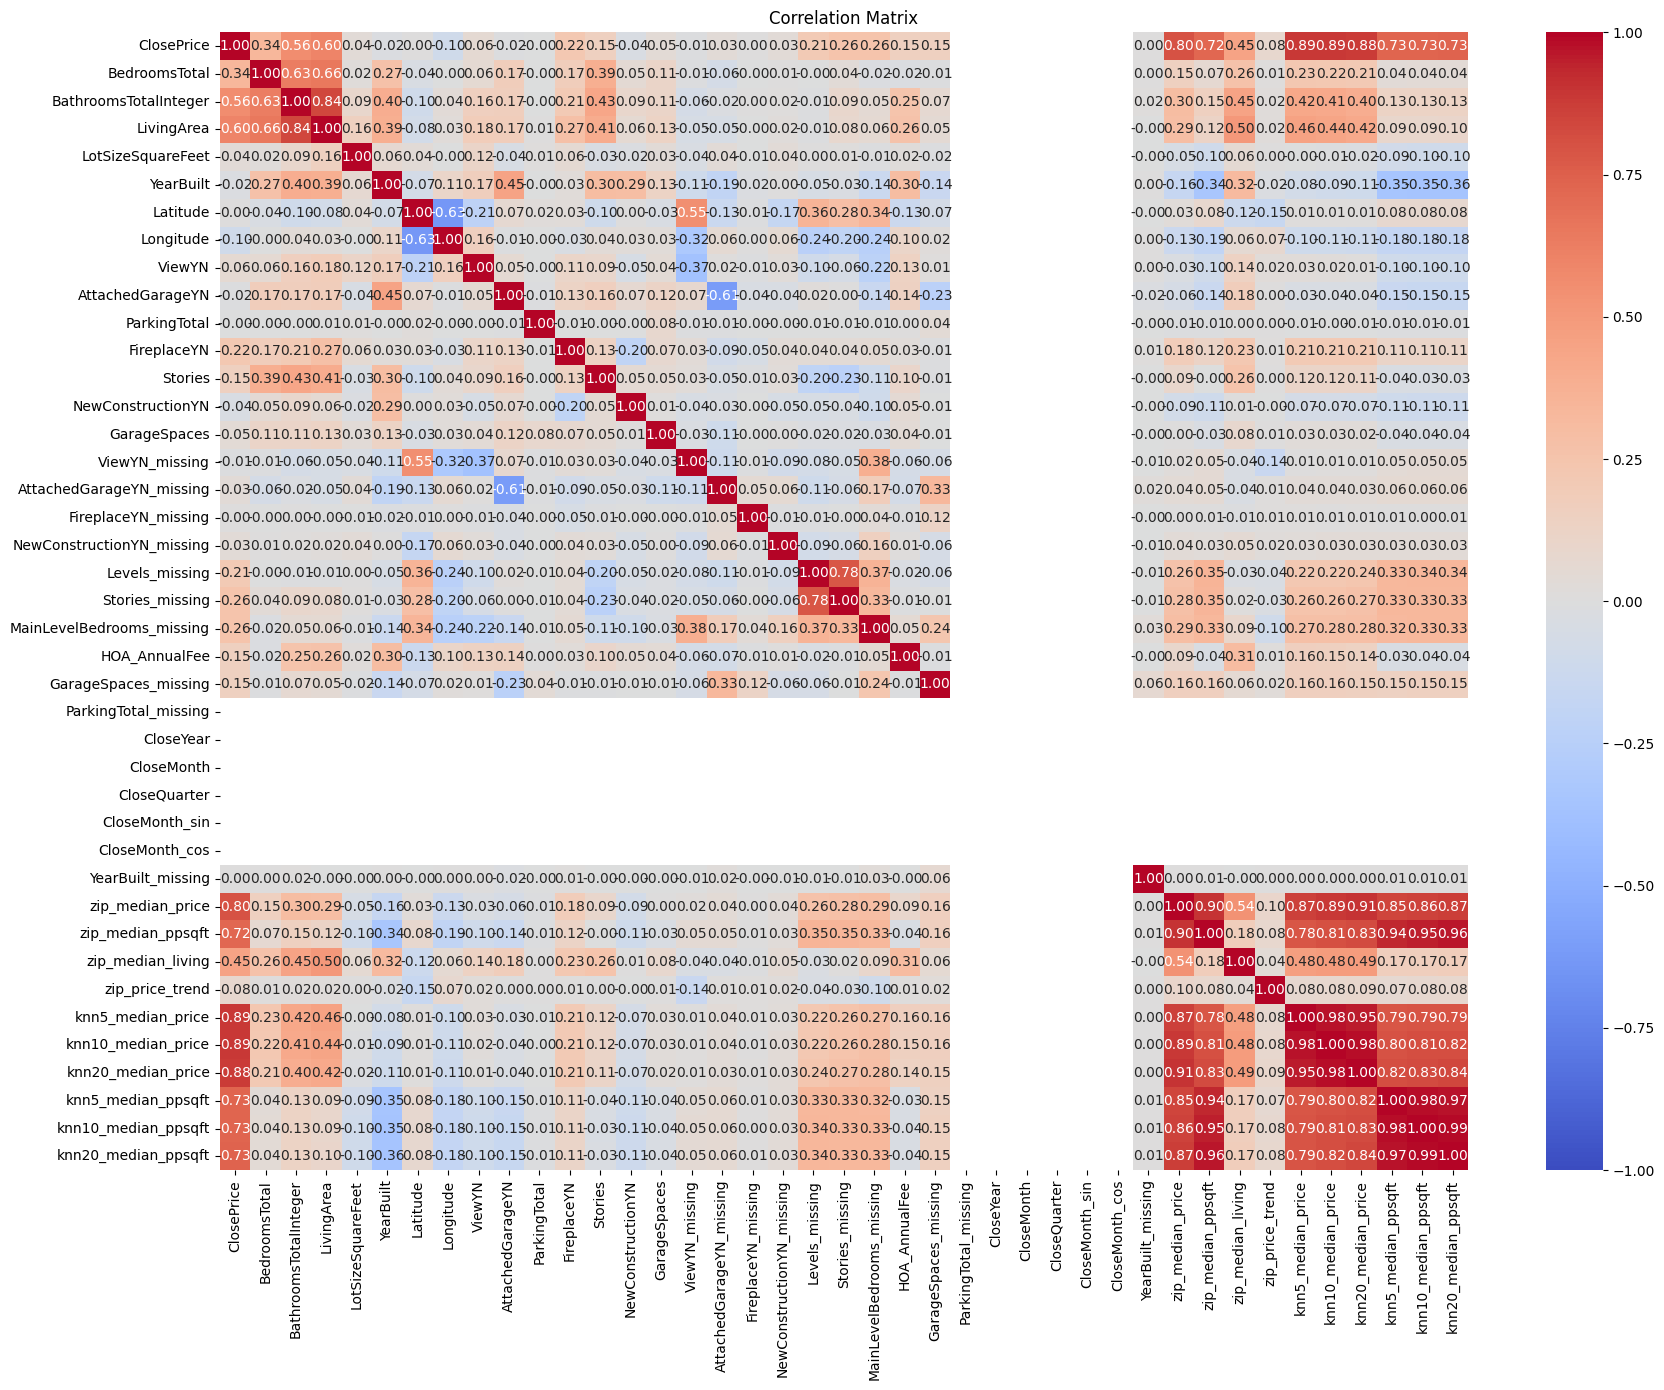

In [185]:
# Select numeric columns only
numeric_cols = train_full.select_dtypes(include=[np.number]).columns

corr = df_test[numeric_cols].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

/tmp/ipykernel_903/915541092.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette="coolwarm")


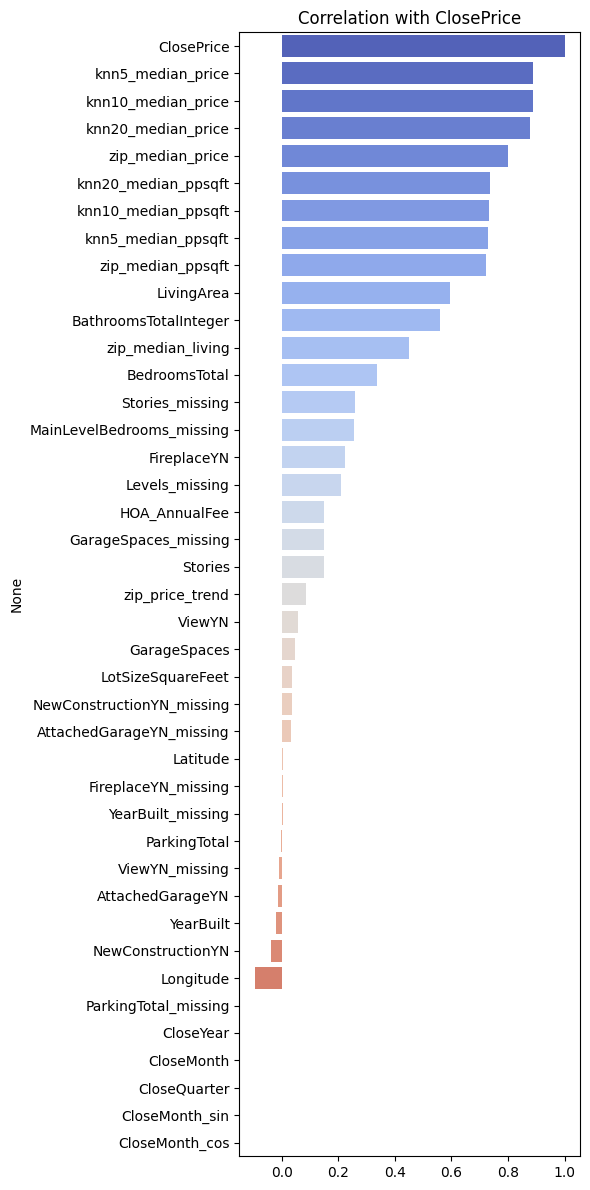

In [184]:
target_corr = corr["ClosePrice"].sort_values(ascending=False)

plt.figure(figsize=(6, 12))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="coolwarm")
plt.title("Correlation with ClosePrice")
plt.tight_layout()
plt.show()